In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras

np.random.seed(42)
tf.random.set_seed(42)

I0000 00:00:1788073776.066396    6957 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1788073776.126162    6957 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1788073777.500108    6957 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [2]:
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import warnings
warnings.filterwarnings("ignore") # Suppresses convergence warnings

In [3]:
data = pd.read_csv(
    "daily_sales.csv",
    parse_dates=["date"],
    index_col="date"
)

data = data.sort_index()

values = data["sales"].values.astype(np.float32)

In [4]:
# Check Sunday sales
sundays = data[data.index.weekday == 6]  # Sunday = 6

sundays[["sales"]]

,sales
date,
2016-10-30,5.44
2016-12-11,19.66
2016-12-18,20.33
2017-04-09,12.01
2017-12-17,41.21
2017-12-24,88.85
2017-12-31,71.65
2018-01-14,12.04
2018-04-01,14.64


In [5]:
data.describe()

,sales
count,3107.000000
mean,100.243933
std,51.926804
min,0.000000
25%,61.875000
50%,92.940000
75%,127.515000
max,388.960000


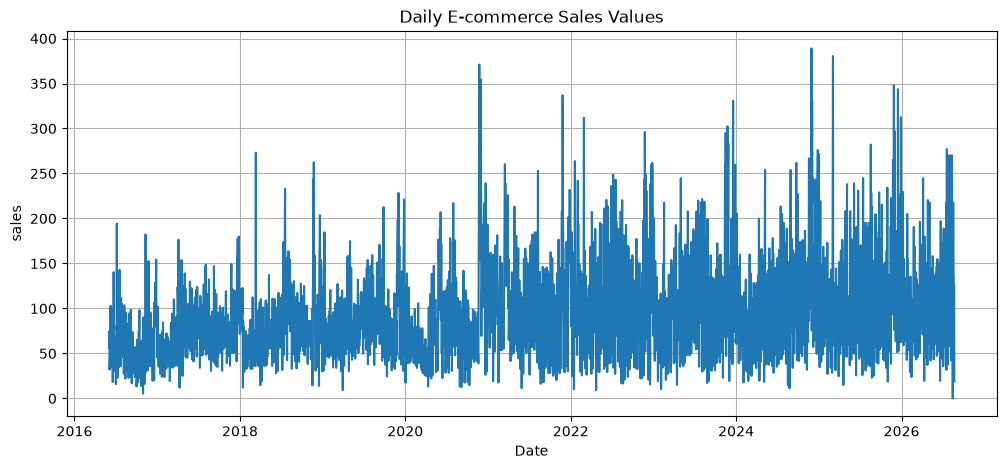

In [6]:
plt.figure(figsize=(12, 5))
plt.plot(data["sales"])
plt.title("Daily E-commerce Sales Values")
plt.xlabel("Date")
plt.ylabel("sales")
plt.grid(True)
plt.show()

In [7]:
from statsmodels.tsa.stattools import adfuller

adf_test = adfuller(data["sales"])
# Output the results
print('ADF Statistic: %f' % adf_test[0])
print('p-value: %f' % adf_test[1])

ADF Statistic: -4.672400
p-value: 0.000095


In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose

# ETS Decomposition
result = seasonal_decompose(
    data["sales"],
    model="additive",
    period=6
)

result.plot()
plt.show()


In [8]:
#keep the original data for later evaluation!
data2 = data.copy()

In [9]:
model_results = []

In [10]:
#Will use data for training, validation and testing up untill 27/6/2026
data = data.loc[:"2026-06-27"]

In [12]:
from sklearn.preprocessing import StandardScaler
import numpy as np
# Extract the values
values = data["sales"].values.astype(np.float32)

# Split into training validation and testing
n = len(values)
train_end = int(n * 0.70)
valid_end = int(n * 0.85)

train_series = values[:train_end]
valid_series = values[train_end:valid_end]
test_series = values[valid_end:]

# Print the length of the datasets to check
print("Number of training samples   : ",len(train_series))
print("Number of validation samples : ",len(valid_series))
print("Number of testing samples    : ",len(test_series))

# Scale the data
scaler = StandardScaler()

# Reshape is required for the scaler
train_series_reshaped = train_series.reshape(-1, 1)
scaler.fit(train_series_reshaped)

# Transform
train_series_scaled = scaler.transform(train_series.reshape(-1, 1)).flatten()
valid_series_scaled = scaler.transform(valid_series.reshape(-1, 1)).flatten()
test_series_scaled = scaler.transform(test_series.reshape(-1, 1)).flatten()

# Function to be used for inverse transformation
def inverse_transform(series, scaler):
    return scaler.inverse_transform(series.reshape(-1, 1)).reshape(series.shape)

Number of training samples   :  2141
Number of validation samples :  459
Number of testing samples    :  459


Shape of Training data   :  (2110, 26, 1) (2110, 6, 1)
Shape of Validation data :  (428, 26, 1) (428, 6, 1)
Shape of Testing data    :  (428, 26, 1) (428, 6, 1)


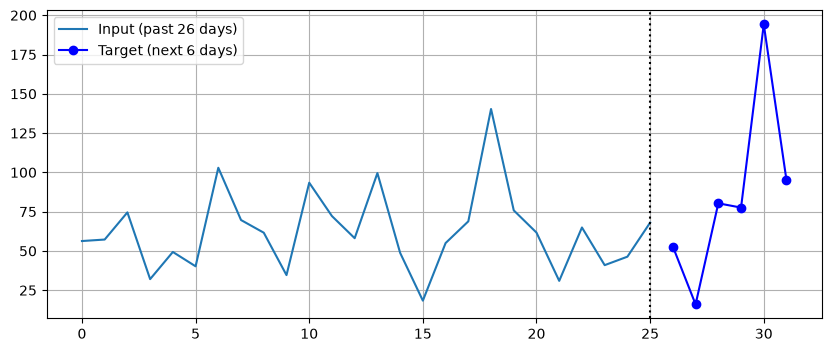

In [13]:
# Past and Future steps
#Monthly transactions are 26 days and we want to predict the next 6 days that is a typical week of sales.
past_steps = 26
future_steps = 6

# Function that makes windows of data to be used with the RNNs
def make_windows(series, past_steps, future_steps):
    X, Y = [], []
    for i in range(len(series) - past_steps - future_steps + 1):
        past = series[i:i + past_steps]
        future = series[i + past_steps:i + past_steps + future_steps]
        X.append(past)
        Y.append(future)
    X = np.array(X)[..., np.newaxis]
    Y = np.array(Y)[..., np.newaxis]
    return X, Y

# Make windows for all datasets
X_train, Y_train = make_windows(train_series_scaled, past_steps, future_steps)
X_valid, Y_valid = make_windows(valid_series_scaled, past_steps, future_steps)
X_test, Y_test = make_windows(test_series_scaled, past_steps, future_steps)

# Print the shapes to ensure they are conforming
print("Shape of Training data   : ", X_train.shape, Y_train.shape)
print("Shape of Validation data : ", X_valid.shape, Y_valid.shape)
print("Shape of Testing data    : ", X_test.shape, Y_test.shape)

# Visualize one training sample and its target
def plot_series(input_seq, target_seq=None, pred_seq=None):
    plt.figure(figsize=(10, 4))
    plt.plot(range(len(input_seq)), input_seq[:, 0], label="Input (past 26 days)")
    
    if target_seq is not None:
        plt.plot(
            range(len(input_seq), len(input_seq) + len(target_seq)),
            target_seq[:, 0],
            "bo-",
            label="Target (next 6 days)"
        )
    
    if pred_seq is not None:
        plt.plot(
            range(len(input_seq), len(input_seq) + len(pred_seq)),
            pred_seq[:, 0],
            "rx--",
            label="Prediction"
        )
    
    plt.axvline(len(input_seq) - 1, color="k", linestyle=":")
    plt.legend()
    plt.grid(True)
    plt.show()

plot_series(inverse_transform(X_train[0],scaler), inverse_transform(Y_train[0],scaler))


E0000 00:00:1788073779.727379    6957 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 26, 32)         │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 26, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 26, 32)         │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 26, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_2 (SimpleRNN)        │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 6)              │           198 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 6, 1)           │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,446 (21.27 KB)

 Trainable params: 5,446 (21.27 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
66/66 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 0.4027 - mae: 0.7592 - val_loss: 0.4802 - val_mae: 0.8533
Epoch 2/200
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.3414 - mae: 0.6815 - val_loss: 0.4615 - val_mae: 0.8269
Epoch 3/200
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.3215 - mae: 0.6553 - val_loss: 0.4417 - val_mae: 0.8003
Epoch 4/200
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.3146 - mae: 0.6465 - val_loss: 0.4392 - val_mae: 0.7984
Epoch 5/200
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.3078 - mae: 0.6360 - val_loss: 0.4347 - val_mae: 0.7920
Epoch 6/200
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.2998 - mae: 0.6253 - val_loss: 0.4267 - val_mae: 0.7833
Epoch 7/200
66/66 ━━━━━━━━━━━━━━━━━━━━ 14s 219ms/step - loss: 0.2938 - mae: 0.6179 - val_loss: 0.4152 - val_mae: 0.7675
Epoch 8/200
66/66 ━━━━━━━━━━━━━━━━━━━━ -13s 10ms/step - loss: 0.2921 - mae: 0.6148 - val_loss: 0.4132 - val_mae: 0.7662
Epoch 9/200
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step 

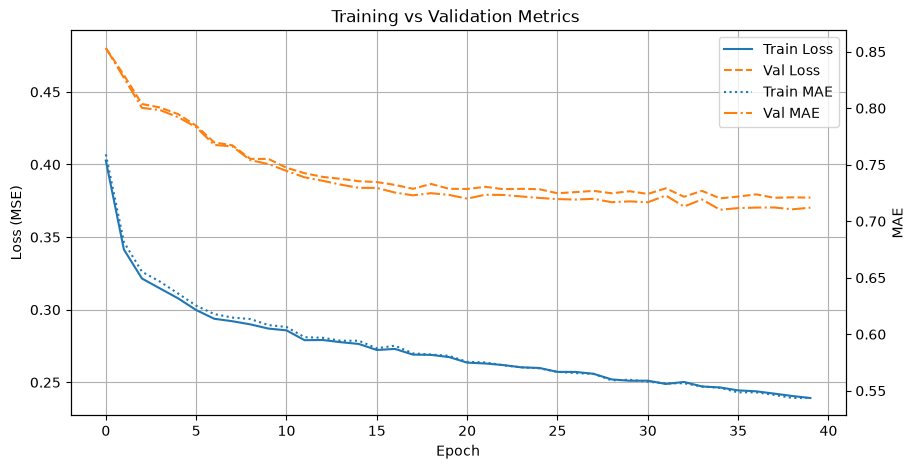

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
Example 0


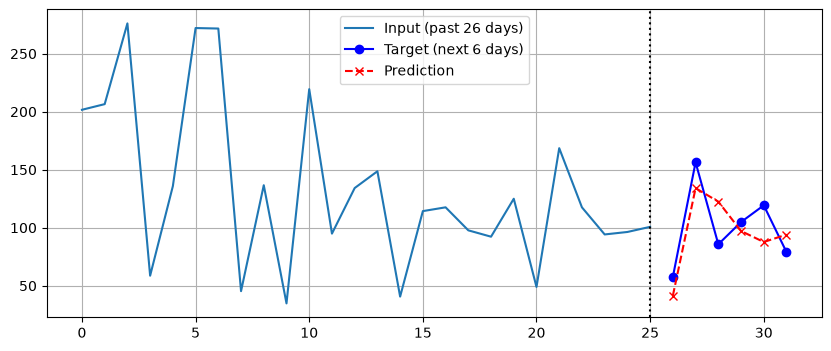

Example 1


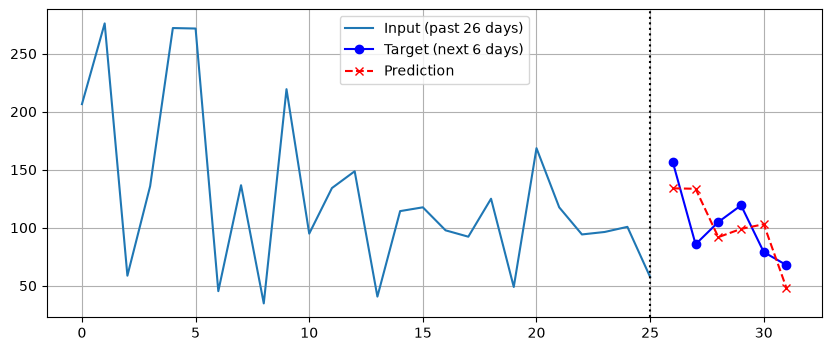

Example 2


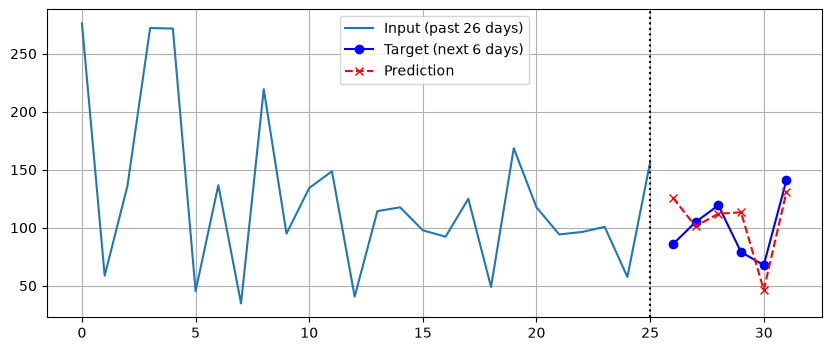

Example 3


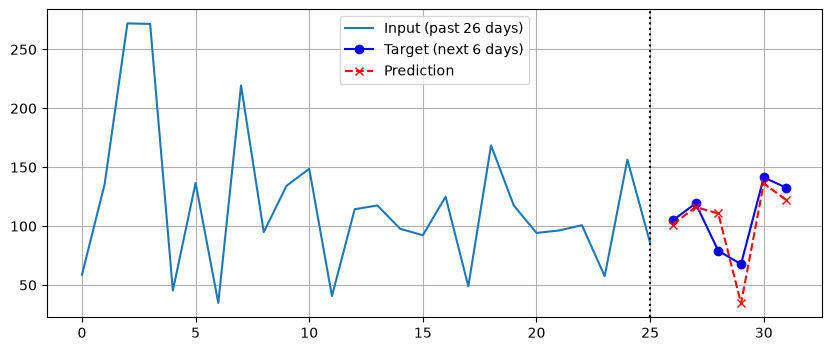

Example 4


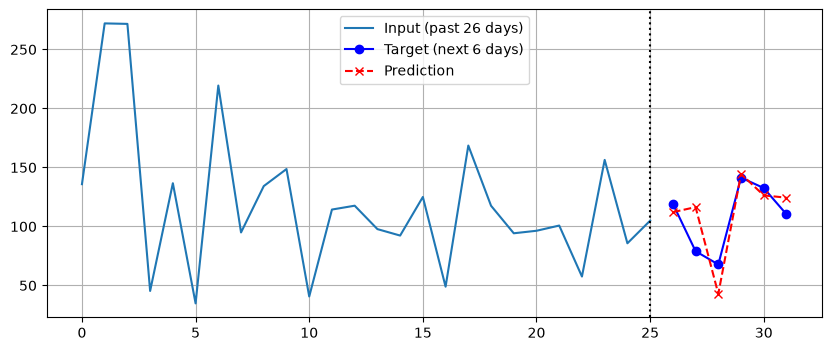

Example 5


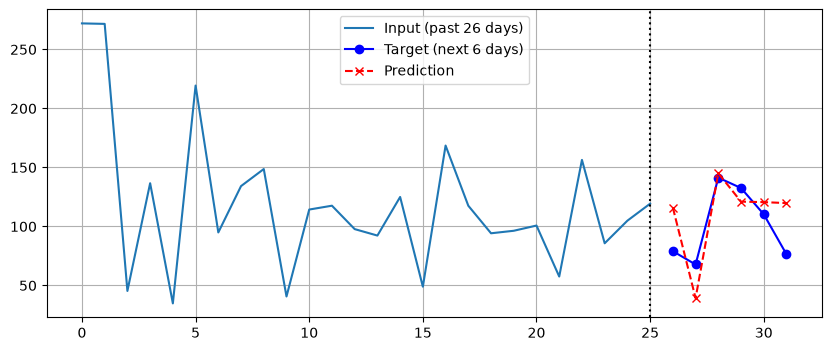

RNN MAE: 31.95087432861328
RNN RMSE: 47.34787368774414


In [14]:
from sklearn.metrics import mean_absolute_error, root_mean_squared_error

# Number of epochs
epochs = 200

# Create default RNN
model_rnn = keras.models.Sequential([
    keras.layers.Input(shape=[past_steps, 1]),
    keras.layers.SimpleRNN(32, return_sequences=True),
    keras.layers.Dropout(0.25),
    keras.layers.SimpleRNN(32, return_sequences=True),
    keras.layers.Dropout(0.25),
    keras.layers.SimpleRNN(32),
    keras.layers.Dense(future_steps),
    keras.layers.Reshape([future_steps, 1])
])

# Compile the model
model_rnn.compile(loss=tf.keras.losses.Huber(), optimizer="adam", metrics=["mae"])

# Summarize
model_rnn.summary()

# Early Stopping
early_stopping = keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)

# Train
history_rnn = model_rnn.fit(
    X_train, Y_train,
    epochs=epochs,
    validation_data=(X_valid, Y_valid),
    callbacks=[early_stopping],
    verbose=1
)

# Plot Loss and MAE for training and validation
fig, ax1 = plt.subplots(figsize=(10, 5))

# Loss (left axis)
ax1.plot(history_rnn.history["loss"], label="Train Loss")
ax1.plot(history_rnn.history["val_loss"], label="Val Loss", linestyle="--")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss (MSE)")
ax1.grid(True)

# MAE (right axis)
ax2 = ax1.twinx()
ax2.plot(history_rnn.history["mae"], label="Train MAE", linestyle=":")
ax2.plot(history_rnn.history["val_mae"], label="Val MAE", linestyle="-.")
ax2.set_ylabel("MAE")

# Title
plt.title("Training vs Validation Metrics ")

# Combined legend
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()

ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="upper right")

plt.show()

# Predict for the test set
Y_pred_rnn = model_rnn.predict(X_test)

# Plot the first six samples along with corresponding targets and predictions
for i in range(6):
    print(f"Example {i}")
    plot_series(
        inverse_transform(X_test[i],scaler),
        inverse_transform(Y_test[i],scaler),
        inverse_transform(Y_pred_rnn[i],scaler)
    )

# MAE and RMSE for RNN
mae_rnn = mean_absolute_error(
    inverse_transform(Y_test.reshape(-1),scaler),
    inverse_transform(Y_pred_rnn.reshape(-1),scaler)
)

rmse_rnn = root_mean_squared_error(
    inverse_transform(Y_test.reshape(-1),scaler),
    inverse_transform(Y_pred_rnn.reshape(-1),scaler)
)

# Print MAE and RMSE
print("RNN MAE:", mae_rnn)
print("RNN RMSE:", rmse_rnn)

model_results.append({
    "Model": "RNN",
    "MAE": mae_rnn,
    "RMSE": rmse_rnn
})


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 26, 32)         │         3,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 26, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 26, 32)         │         6,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 26, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_2 (GRU)                     │ (None, 26, 32)         │         6,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 26, 6)          │           198 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,230 (63.40 KB)

 Trainable params: 16,230 (63.40 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
132/132 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - loss: 0.3459 - mae: 0.6879 - val_loss: 0.5249 - val_mae: 0.8991
Epoch 2/200
132/132 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - loss: 0.3332 - mae: 0.6679 - val_loss: 0.5168 - val_mae: 0.8905
Epoch 3/200
132/132 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 0.3267 - mae: 0.6598 - val_loss: 0.4936 - val_mae: 0.8645
Epoch 4/200
132/132 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - loss: 0.3184 - mae: 0.6500 - val_loss: 0.4599 - val_mae: 0.8265
Epoch 5/200
132/132 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 0.3083 - mae: 0.6383 - val_loss: 0.4193 - val_mae: 0.7774
Epoch 6/200
132/132 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - loss: 0.2964 - mae: 0.6224 - val_loss: 0.3931 - val_mae: 0.7404
Epoch 7/200
132/132 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 0.2881 - mae: 0.6102 - val_loss: 0.3846 - val_mae: 0.7258
Epoch 8/200
132/132 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - loss: 0.2821 - mae: 0.6010 - val_loss: 0.3814 - val_mae: 0.7209
Epoch 9/200
132/132 ━━━━━━━━━━━━━━━━━━━━

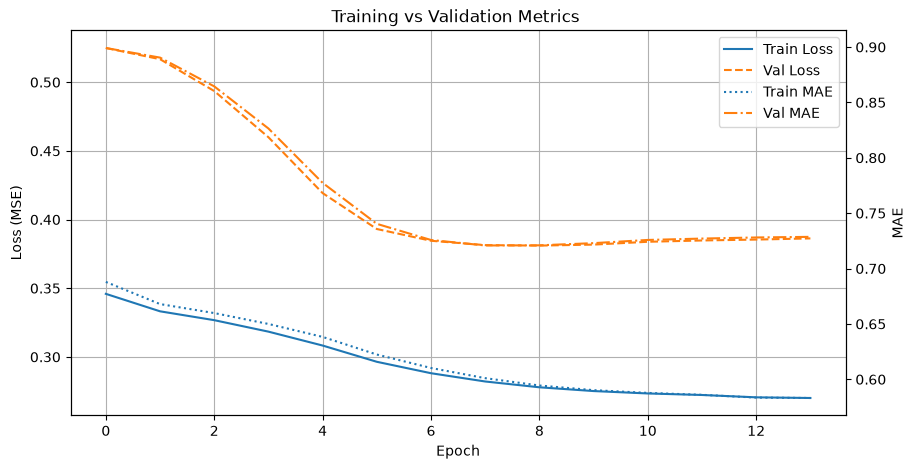

14/14 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step
Example 0


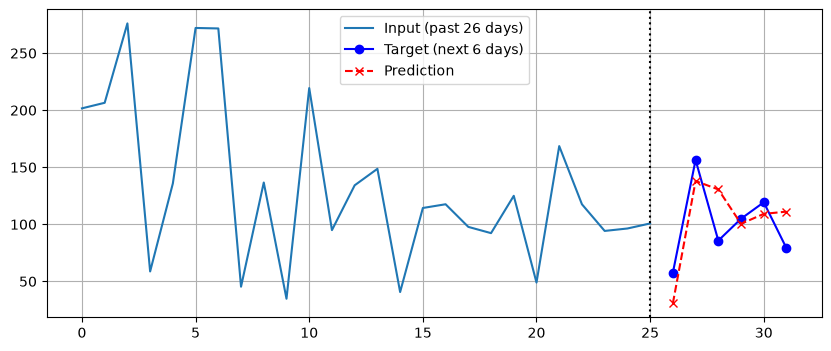

Example 1


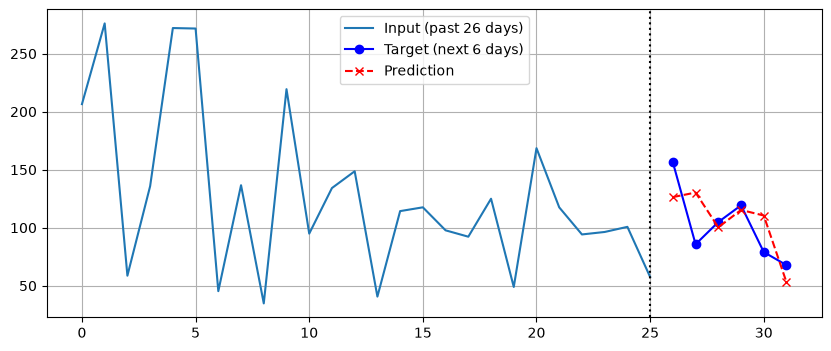

Example 2


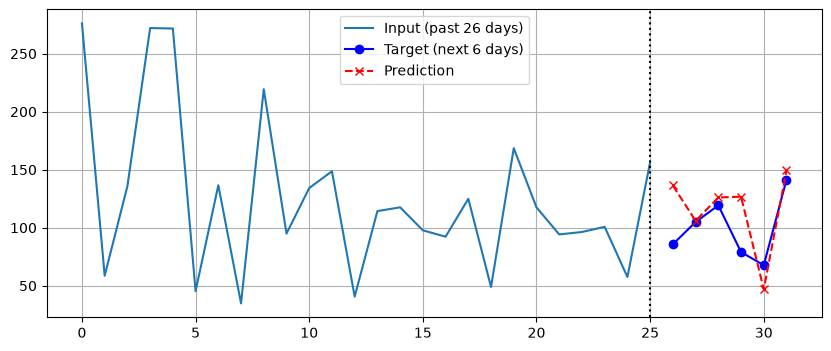

Example 3


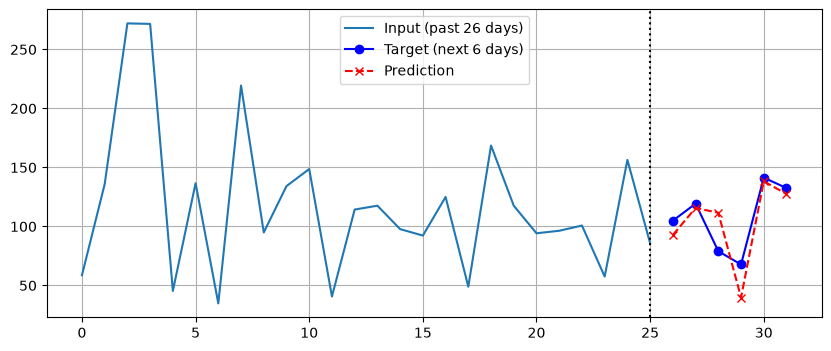

Example 4


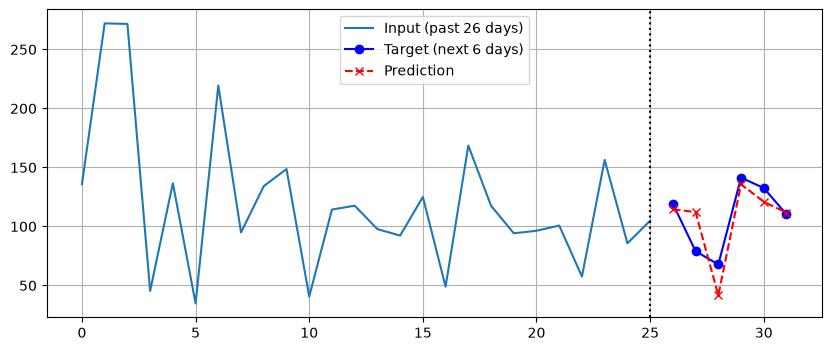

Example 5


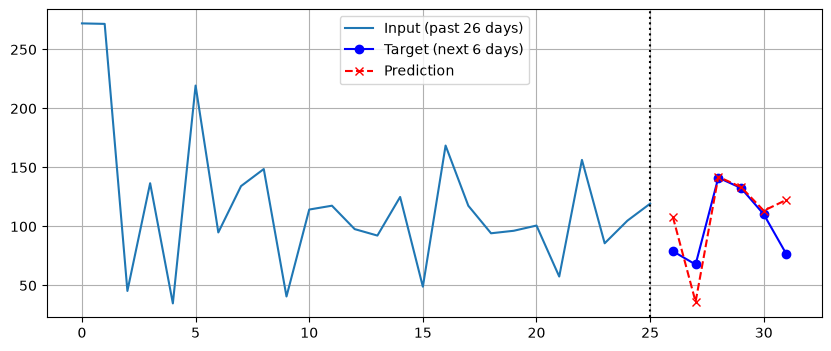

GRU MAE: 33.2940559387207
GRU RMSE: 48.56705856323242


In [15]:
# Function what creates windows
def to_windows(dataset, length):
    dataset = dataset.window(length, shift=1, drop_remainder=True)
    return dataset.flat_map(lambda window_ds: window_ds.batch(length))

# Function that creates the tensor form for training
def to_seq2seq_dataset(series, seq_length=past_steps, ahead=future_steps, target_col=0, batch_size=16, shuffle=False, seed=42):
    ds = to_windows(tf.data.Dataset.from_tensor_slices(series), ahead + 1)
    ds = to_windows(ds, seq_length).map(lambda S: (S[:, 0, :], S[:, 1:, target_col]))
    if shuffle:
        ds = ds.shuffle(8 * batch_size, seed=seed)
    return ds.batch(batch_size)

train_series_scaled_seq = to_seq2seq_dataset(train_series_scaled.reshape(-1, 1))
valid_series_scaled_seq = to_seq2seq_dataset(valid_series_scaled.reshape(-1, 1))
test_series_scaled_seq = to_seq2seq_dataset(test_series_scaled.reshape(-1, 1))

# Create default GRU
model_gru = keras.models.Sequential([
    keras.layers.Input(shape=[past_steps, 1]),
    keras.layers.GRU(32, return_sequences=True),
    keras.layers.Dropout(0.25),
    keras.layers.GRU(32, return_sequences=True),
    keras.layers.Dropout(0.25),
    keras.layers.GRU(32, return_sequences=True),
    keras.layers.Dense(future_steps)
])

# Compile the model
model_gru.compile(loss=tf.keras.losses.Huber(), optimizer="adam", metrics=["mae"])

# Summarize
model_gru.summary()

# Early Stopping
early_stopping = keras.callbacks.EarlyStopping(
    patience=5,
    restore_best_weights=True
)

# Train
history_gru = model_gru.fit(
    train_series_scaled_seq,
    epochs=epochs,
    validation_data=valid_series_scaled_seq,
    callbacks=[early_stopping],
    verbose=1
)

# Plot Loss and MAE for training and validation
fig, ax1 = plt.subplots(figsize=(10, 5))

# Loss (left axis)
ax1.plot(history_gru.history["loss"], label="Train Loss")
ax1.plot(history_gru.history["val_loss"], label="Val Loss", linestyle="--")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss (MSE)")
ax1.grid(True)

# MAE (right axis)
ax2 = ax1.twinx()
ax2.plot(history_gru.history["mae"], label="Train MAE", linestyle=":")
ax2.plot(history_gru.history["val_mae"], label="Val MAE", linestyle="-.")
ax2.set_ylabel("MAE")

# Title
plt.title("Training vs Validation Metrics ")

# Combined legend
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()

ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="upper right")

plt.show()

# Predict for the test set
Y_pred_gru = model_gru.predict(X_test)

# Keep only the prediction at the last input time step
Y_pred_gru = Y_pred_gru[:, -1, :]          # shape: (n_samples, future_steps)

# Reshape to match Y_test: (n_samples, future_steps, 1)
Y_pred_gru = Y_pred_gru[..., np.newaxis]

# Plot the first six samples along with corresponding targets and predictions
for i in range(6):
    print(f"Example {i}")
    plot_series(
        inverse_transform(X_test[i],scaler),
        inverse_transform(Y_test[i],scaler),
        inverse_transform(Y_pred_gru[i],scaler)
    )

# MAE and RMSE for RNN
mae_gru = mean_absolute_error(
    inverse_transform(Y_test.reshape(-1),scaler),
    inverse_transform(Y_pred_gru.reshape(-1),scaler)
)

rmse_gru = root_mean_squared_error(
    inverse_transform(Y_test.reshape(-1),scaler),
    inverse_transform(Y_pred_gru.reshape(-1),scaler)
)

# Print MAE and RMSE
print("GRU MAE:", mae_gru)
print("GRU RMSE:", rmse_gru)

model_results.append({
    "Model": "GRU",
    "MAE": mae_gru,
    "RMSE": rmse_gru
})


In [16]:

# naive forecast: tomorrow = today
naive_pred = test_series[:-1]
naive_true = test_series[1:]

naive_mae = mean_absolute_error(naive_true, naive_pred)
naive_rmse = np.sqrt(mean_squared_error(naive_true, naive_pred))

print("Naive MAE:", naive_mae)
print("Naive RMSE:", naive_rmse)

model_results.append({
    "Model": "Naive",
    "MAE": naive_mae,
    "RMSE": naive_rmse
})

Naive MAE: 62.35860824584961
Naive RMSE: 81.80078041058808


In [17]:
#Calculate Arima and Sarima models as baseline to compare with the results of the NNs
arima_model = ARIMA(train_series, order=(1, 1, 1))
arima_fit = arima_model.fit()
arima_pred = arima_fit.forecast(steps=len(test_series))

arima_mae = mean_absolute_error(test_series, arima_pred)
arima_rmse = np.sqrt(mean_squared_error(test_series, arima_pred))

print(f"ARIMA MAE: {arima_mae:.2f}")
print(f"ARIMA RMSE: {arima_rmse:.2f}")

model_results.append({
    "Model": "ARIMA",
    "MAE": arima_mae,
    "RMSE": arima_rmse
})


# Set s=7 if keeping a natural week, or s=6 if you dropped Sundays.
sarima_model = SARIMAX(
    train_series, 
    order=(1, 1, 1), 
    seasonal_order=(1, 1, 1, 6) 
)
sarima_fit = sarima_model.fit(disp=False)
sarima_pred = sarima_fit.forecast(steps=len(test_series))

sarima_mae = mean_absolute_error(test_series, sarima_pred)
sarima_rmse = np.sqrt(mean_squared_error(test_series, sarima_pred))

print(f"SARIMA MAE: {sarima_mae:.2f}")
print(f"SARIMA RMSE: {sarima_rmse:.2f}")

model_results.append({
    "Model": "SARIMA",
    "MAE": sarima_mae,
    "RMSE": sarima_rmse
})

ARIMA MAE: 41.62
ARIMA RMSE: 55.78
SARIMA MAE: 42.65
SARIMA RMSE: 56.80


I will now transform the data by adding all Sundays and with 3 new columns indicating if its Sundau, Monday and Saturday. Reasoning is that this way the model will predict 7 days instead of 6 while changing the window to 28 from 26. Also since the e-shop is usually closed Sundays and always Saturday is open half the normal hours I want the model to capture that . As a result Monday has higher daily sales than the other days and Saturday has less than Friday.

In [18]:
# create full daily date range
full_index = pd.date_range(
    start=data.index.min(),
    end=data.index.max(),
    freq="D"
)

# add missing days
data = data.reindex(full_index)

# fill missing sales with 0
data["sales"] = data["sales"].fillna(0)

# date features
data["is_monday"] = (data.index.weekday == 0).astype(np.float32)
data["is_saturday"] = (data.index.weekday == 5).astype(np.float32)
data["is_sunday"] = (data.index.weekday == 6).astype(np.float32)

In [19]:
past_steps = 28
future_steps = 7
batch_size = 16
epochs = 200

In [20]:
sales_values = data["sales"].values.astype(np.float32)

n = len(sales_values)
train_end = int(n * 0.70)
valid_end = int(n * 0.85)

train_sales = sales_values[:train_end]
valid_sales = sales_values[train_end:valid_end]
test_sales = sales_values[valid_end:]

scaler = StandardScaler()
scaler.fit(train_sales.reshape(-1, 1))

train_sales_scaled = scaler.transform(train_sales.reshape(-1, 1)).flatten()
valid_sales_scaled = scaler.transform(valid_sales.reshape(-1, 1)).flatten()
test_sales_scaled = scaler.transform(test_sales.reshape(-1, 1)).flatten()

In [21]:
features = data[["is_monday", "is_saturday", "is_sunday"]].values.astype(np.float32)

train_features = features[:train_end]
valid_features = features[train_end:valid_end]
test_features = features[valid_end:]

train_series_scaled = np.column_stack([train_sales_scaled, train_features])
valid_series_scaled = np.column_stack([valid_sales_scaled, valid_features])
test_series_scaled = np.column_stack([test_sales_scaled, test_features])

In [22]:
train_series_scaled_seq = to_seq2seq_dataset(
    train_series_scaled,
    seq_length=past_steps,
    ahead=future_steps,
    batch_size=batch_size,
    shuffle=True
)

valid_series_scaled_seq = to_seq2seq_dataset(
    valid_series_scaled,
    seq_length=past_steps,
    ahead=future_steps,
    batch_size=batch_size
)

test_series_scaled_seq = to_seq2seq_dataset(
    test_series_scaled,
    seq_length=past_steps,
    ahead=future_steps,
    batch_size=batch_size
)

In [23]:
for X_batch, Y_batch in train_series_scaled_seq.take(1):
    print("X_batch:", X_batch.shape)
    print("Y_batch:", Y_batch.shape)

X_batch: (16, 28, 4)
Y_batch: (16, 28, 7)


In [24]:
def dataset_to_numpy(ds):
    X_list = []
    Y_list = []

    for X_batch, Y_batch in ds:
        X_list.append(X_batch.numpy())
        Y_list.append(Y_batch.numpy())

    X = np.concatenate(X_list, axis=0)
    Y = np.concatenate(Y_list, axis=0)

    return X, Y

In [25]:
X_train, Y_train = dataset_to_numpy(train_series_scaled_seq)
X_valid, Y_valid = dataset_to_numpy(valid_series_scaled_seq)
X_test, Y_test = dataset_to_numpy(test_series_scaled_seq)

In [26]:
#New GRU model with 4 inputs instead of 1
new_gru = keras.models.Sequential([
    keras.layers.Input(shape=[past_steps, 4]),
    keras.layers.GRU(32, return_sequences=True),
    keras.layers.GRU(32, return_sequences=True),
    keras.layers.GRU(32, return_sequences=True),
    keras.layers.Dense(future_steps)
])

# Compile the model
new_gru.compile(loss=tf.keras.losses.Huber(), optimizer="adam", metrics=["mae"])

# Summarize
new_gru.summary()

# Early Stopping
early_stopping = keras.callbacks.EarlyStopping(
    patience=5,
    restore_best_weights=True
)

# Train
history_new_gru = new_gru.fit(
    train_series_scaled_seq,
    epochs=epochs,
    validation_data=valid_series_scaled_seq,
    callbacks=[early_stopping],
    verbose=1
)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_3 (GRU)                     │ (None, 28, 32)         │         3,648 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_4 (GRU)                     │ (None, 28, 32)         │         6,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_5 (GRU)                     │ (None, 28, 32)         │         6,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 28, 7)          │           231 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,551 (64.65 KB)

 Trainable params: 16,551 (64.65 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
159/159 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - loss: 0.2872 - mae: 0.6136 - val_loss: 0.3022 - val_mae: 0.6089
Epoch 2/200
159/159 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - loss: 0.2005 - mae: 0.4788 - val_loss: 0.2759 - val_mae: 0.5647
Epoch 3/200
159/159 ━━━━━━━━━━━━━━━━━━━━ -10s -65710us/step - loss: 0.1914 - mae: 0.4588 - val_loss: 0.2732 - val_mae: 0.5570
Epoch 4/200
159/159 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - loss: 0.1880 - mae: 0.4514 - val_loss: 0.2676 - val_mae: 0.5485
Epoch 5/200
159/159 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - loss: 0.1859 - mae: 0.4470 - val_loss: 0.2629 - val_mae: 0.5413
Epoch 6/200
159/159 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - loss: 0.1851 - mae: 0.4450 - val_loss: 0.2605 - val_mae: 0.5373
Epoch 7/200
159/159 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - loss: 0.1838 - mae: 0.4425 - val_loss: 0.2600 - val_mae: 0.5367
Epoch 8/200
159/159 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - loss: 0.1826 - mae: 0.4401 - val_loss: 0.2592 - val_mae: 0.5375
Epoch 9/200
159/159 ━━━━━━━━━━━━━━

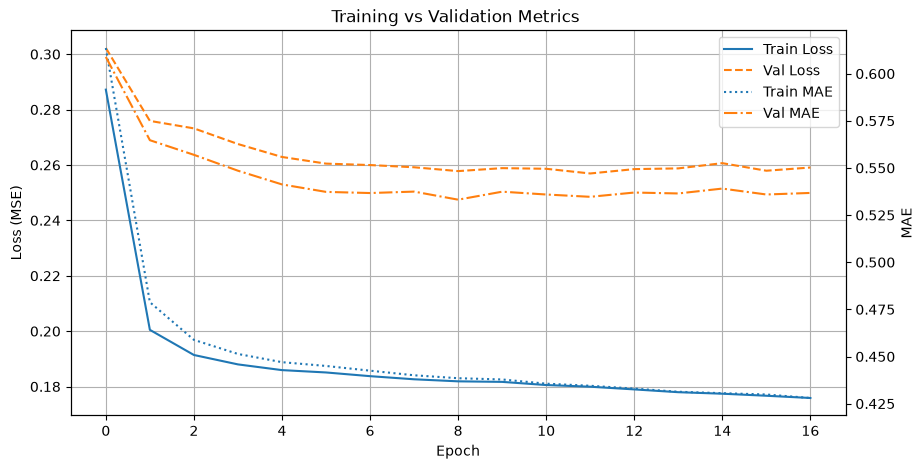

17/17 ━━━━━━━━━━━━━━━━━━━━ 14s 872ms/step
Raw Y_test shape: (518, 28, 7)
Raw Y_pred_new_gru shape: (518, 28, 7)


In [27]:
# Plot Loss and MAE for training and validation
fig, ax1 = plt.subplots(figsize=(10, 5))

# Loss (left axis)
ax1.plot(history_new_gru .history["loss"], label="Train Loss")
ax1.plot(history_new_gru .history["val_loss"], label="Val Loss", linestyle="--")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss (MSE)")
ax1.grid(True)

# MAE (right axis)
ax2 = ax1.twinx()
ax2.plot(history_new_gru .history["mae"], label="Train MAE", linestyle=":")
ax2.plot(history_new_gru .history["val_mae"], label="Val MAE", linestyle="-.")
ax2.set_ylabel("MAE")

# Title
plt.title("Training vs Validation Metrics ")

# Combined legend
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()

ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="upper right")

plt.show()

# Predict
Y_pred_new_gru = new_gru.predict(X_test)

print("Raw Y_test shape:", Y_test.shape)
print("Raw Y_pred_new_gru shape:", Y_pred_new_gru.shape)



Final Y_test_last shape: (518, 7, 1)
Final Y_pred_new_gru shape: (518, 7, 1)
NEW GRU MAE: 28.254667282104492
NEW GRU RMSE: 44.368892669677734
Example 0


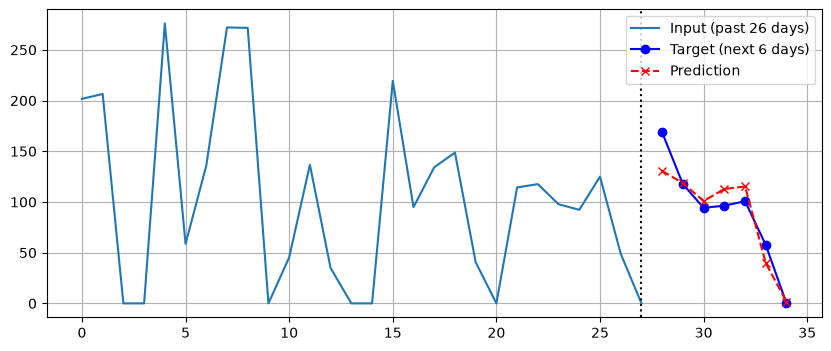

Example 1


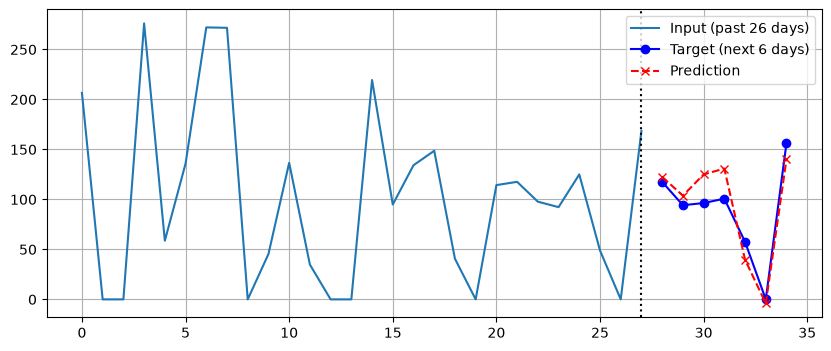

Example 2


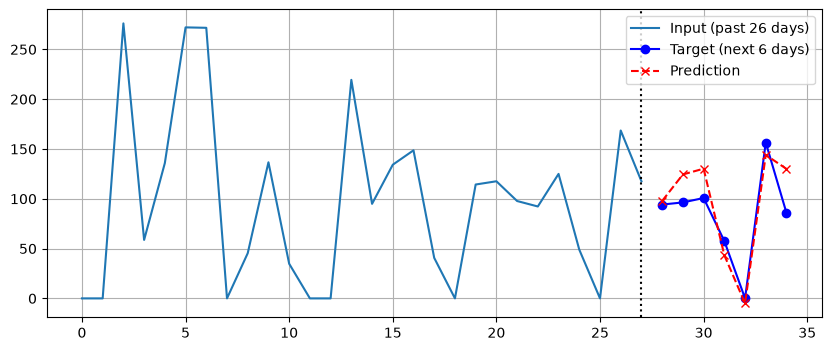

Example 3


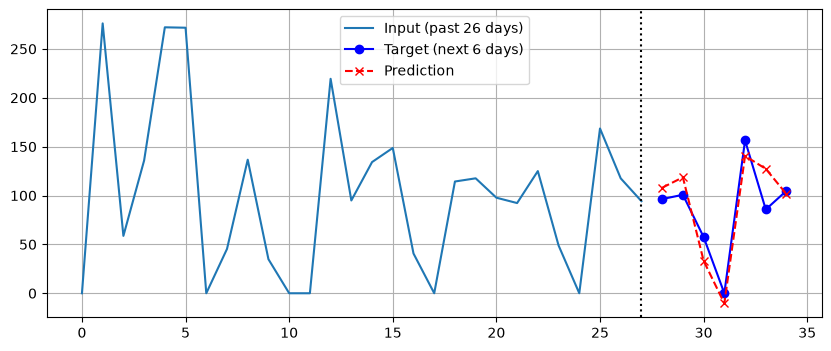

Example 4


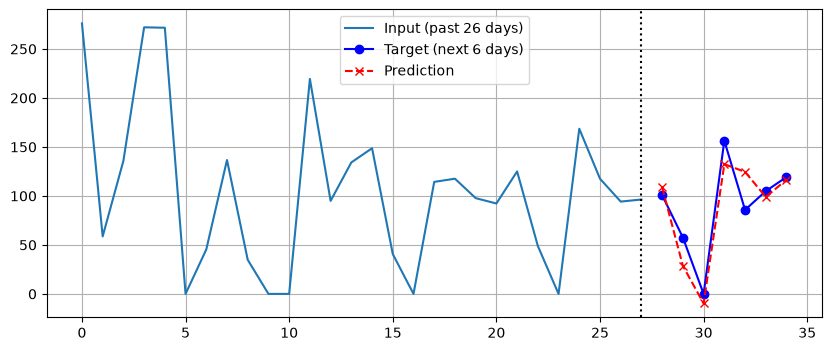

Example 5


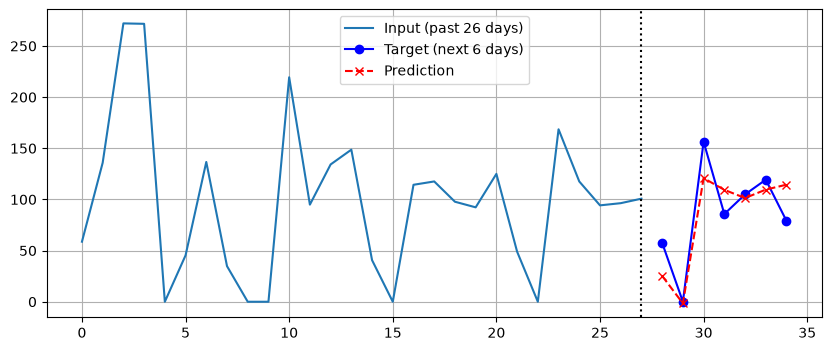

In [28]:
# Keep only last timestep forecast
Y_pred_new_gru = Y_pred_new_gru[:, -1, :]              # (samples, future_steps)
Y_pred_new_gru = Y_pred_new_gru[..., np.newaxis]       # (samples, future_steps, 1)

# Keep only last timestep target
Y_test_last = Y_test[:, -1, :]                         # (samples, future_steps)
Y_test_last = Y_test_last[..., np.newaxis]             # (samples, future_steps, 1)

print("Final Y_test_last shape:", Y_test_last.shape)
print("Final Y_pred_new_gru shape:", Y_pred_new_gru.shape)

mae_new_gru = mean_absolute_error(
    inverse_transform(Y_test_last.reshape(-1), scaler),
    inverse_transform(Y_pred_new_gru.reshape(-1), scaler)
)

rmse_new_gru = root_mean_squared_error(
    inverse_transform(Y_test_last.reshape(-1), scaler),
    inverse_transform(Y_pred_new_gru.reshape(-1), scaler)
)

print("NEW GRU MAE:", mae_new_gru)
print("NEW GRU RMSE:", rmse_new_gru)

for i in range(6):
    print(f"Example {i}")

    plot_series(
        inverse_transform(X_test[i, :, 0].reshape(-1, 1), scaler),
        inverse_transform(Y_test_last[i].reshape(-1, 1), scaler),
        inverse_transform(Y_pred_new_gru[i].reshape(-1, 1), scaler)
    )

In [29]:
model_results.append({
    "Model": "NEW GRU",
    "MAE": float(mae_new_gru),
    "RMSE": float(rmse_new_gru)
})

In [30]:
results_df = pd.DataFrame(model_results)
results_df.sort_values("MAE")

,Model,MAE,RMSE
5,NEW GRU,28.254667,44.368893
0,RNN,31.950874,47.347874
1,GRU,33.294056,48.567059
3,ARIMA,41.622227,55.783391
4,SARIMA,42.647306,56.799006
2,Naive,62.358608,81.800780


In [31]:
print("X_train:", X_train.shape)
print("Y_train:", Y_train.shape)
print("X_valid:", X_valid.shape)
print("Y_valid:", Y_valid.shape)
print("X_test:", X_test.shape)
print("Y_test:", Y_test.shape)

X_train: (2541, 28, 4)
Y_train: (2541, 28, 7)
X_valid: (518, 28, 4)
Y_valid: (518, 28, 7)
X_test: (518, 28, 4)
Y_test: (518, 28, 7)


In [32]:
train_dates = data.index[:train_end]
valid_dates = data.index[train_end:valid_end]
test_dates = data.index[valid_end:]

print("Train:", train_dates.min(), "to", train_dates.max())
print("Valid:", valid_dates.min(), "to", valid_dates.max())
print("Test :", test_dates.min(), "to", test_dates.max())

print(train_dates.max() < valid_dates.min())
print(valid_dates.max() < test_dates.min())

Train: 2016-06-01 00:00:00 to 2023-06-19 00:00:00
Valid: 2023-06-20 00:00:00 to 2024-12-22 00:00:00
Test : 2024-12-23 00:00:00 to 2026-06-27 00:00:00
True
True


In [33]:
Y_test_eval = Y_test_last[::future_steps]
Y_pred_eval = Y_pred_new_gru[::future_steps]

mae_strict = mean_absolute_error(
    inverse_transform(Y_test_eval.reshape(-1), scaler),
    inverse_transform(Y_pred_eval.reshape(-1), scaler)
)

rmse_strict = root_mean_squared_error(
    inverse_transform(Y_test_eval.reshape(-1), scaler),
    inverse_transform(Y_pred_eval.reshape(-1), scaler)
)

print("Strict non-overlap MAE:", mae_strict)
print("Strict non-overlap RMSE:", rmse_strict)

Strict non-overlap MAE: 26.961332321166992
Strict non-overlap RMSE: 44.00385665893555


In [34]:
model_results.append({
    "Model": "NEW GRU 28/7 + Weekday Flags Strict",
    "MAE": float(mae_strict),
    "RMSE": float(rmse_strict)
})

Now that we have our models I will use actual data for prediction and make comparisons. I have seperated the data from 26/6 till 22/8 and I will use each week to make Predicitions without giving the actual data to the model. Then I will compare the results , add the week to the data retrain and make a new prediction for the next week again without giving the results to the model.

In [35]:
# Actual sales for real walk-forward evaluation
actual_sales = data2.loc["2026-06-29":"2026-08-22"].copy()

# Keep only Monday-Saturday
actual_sales = actual_sales[actual_sales.index.weekday != 6].copy()

# Keep only target column
actual_sales = actual_sales[["sales"]].copy()

# Add useful evaluation columns
actual_sales["forecast_date"] = actual_sales.index
actual_sales["week_start"] = actual_sales["forecast_date"] - pd.to_timedelta(
    actual_sales["forecast_date"].dt.weekday, unit="D"
)

actual_sales["horizon"] = actual_sales.groupby("week_start").cumcount() + 1

# Clean column names
actual_sales = actual_sales.rename(columns={"sales": "y_true"})

# Final shape
actual_sales = actual_sales.reset_index(drop=True)

actual_sales.head(10)

,y_true,forecast_date,week_start,horizon
0,173.73,2026-06-29,2026-06-29,1
1,138.39,2026-06-30,2026-06-29,2
2,132.92,2026-07-01,2026-06-29,3
3,172.33,2026-07-02,2026-06-29,4
4,125.24,2026-07-03,2026-06-29,5
5,35.86,2026-07-04,2026-06-29,6
6,188.85,2026-07-06,2026-07-06,1
7,125.74,2026-07-07,2026-07-06,2
8,111.85,2026-07-08,2026-07-06,3
9,124.48,2026-07-09,2026-07-06,4


In [36]:
actual_sales.groupby("week_start").size()

week_start
2026-06-29    6
2026-07-06    6
2026-07-13    6
2026-07-20    6
2026-07-27    6
2026-08-03    6
2026-08-10    6
2026-08-17    6
dtype: int64

In [37]:
past_steps = 26
future_steps = 6
target_col = "sales"

def scale_current_history(current_history, target_col="sales"):
    scaler = StandardScaler()

    sales = current_history[target_col].values.astype(np.float32)
    sales_scaled = scaler.fit_transform(sales.reshape(-1, 1)).astype(np.float32)

    return sales_scaled, scaler


In [38]:
def prepare_base_model_data(
    current_history,
    target_col="sales",
    past_steps=26,
    future_steps=6,
    batch_size=16
):
    sales_scaled, scaler = scale_current_history(current_history, target_col=target_col)

    # RNN: seq-to-vector
    X_rnn, Y_rnn = make_windows(
        sales_scaled.reshape(-1),
        past_steps=past_steps,
        future_steps=future_steps
    )

    # GRU: seq-to-seq
    gru_ds = to_seq2seq_dataset(
        sales_scaled,
        seq_length=past_steps,
        ahead=future_steps,
        target_col=0,
        batch_size=batch_size,
        shuffle=False,
        seed=42
    )

    # Last known window for next-week prediction
    X_next = sales_scaled[-past_steps:].reshape(1, past_steps, 1).astype(np.float32)

    return {
        "sales_scaled": sales_scaled,
        "scaler": scaler,
        "X_rnn": X_rnn,
        "Y_rnn": Y_rnn,
        "gru_ds": gru_ds,
        "X_next": X_next
    }

In [39]:
holdout_start = pd.Timestamp("2026-06-29")

current_history = data2.loc[data2.index < holdout_start].copy()
base_data = prepare_base_model_data(
    current_history,
    target_col="sales",
    past_steps=past_steps,
    future_steps=future_steps,
    batch_size=batch_size
)

In [40]:
print(current_history.index.min())
print(current_history.index.max())

2016-06-01 00:00:00
2026-06-27 00:00:00


In [41]:
print("RNN X:", base_data["X_rnn"].shape)
print("RNN Y:", base_data["Y_rnn"].shape)
print("Next window:", base_data["X_next"].shape)

for X_batch, Y_batch in base_data["gru_ds"].take(1):
    print("GRU X batch:", X_batch.shape)
    print("GRU Y batch:", Y_batch.shape)

RNN X: (3028, 26, 1)
RNN Y: (3028, 6, 1)
Next window: (1, 26, 1)
GRU X batch: (16, 26, 1)
GRU Y batch: (16, 26, 6)


In [42]:
def split_windows_time_order(X, Y, valid_ratio=0.15):
    valid_size = int(len(X) * valid_ratio)

    X_train = X[:-valid_size]
    Y_train = Y[:-valid_size]

    X_valid = X[-valid_size:]
    Y_valid = Y[-valid_size:]

    return X_train, Y_train, X_valid, Y_valid

In [43]:
def build_base_rnn(past_steps=26, future_steps=6):
    model_rnn = keras.models.Sequential([
        keras.layers.Input(shape=[past_steps, 1]),
        keras.layers.SimpleRNN(32, return_sequences=True),
        keras.layers.Dropout(0.25),
        keras.layers.SimpleRNN(32, return_sequences=True),
        keras.layers.Dropout(0.25),
        keras.layers.SimpleRNN(32),
        keras.layers.Dense(future_steps),
        keras.layers.Reshape([future_steps, 1])
    ])

    model_rnn.compile(
        loss=tf.keras.losses.Huber(),
        optimizer="adam",
        metrics=["mae"]
    )

    return model_rnn

In [44]:
def train_predict_rnn(
    current_history,
    target_col="sales",
    past_steps=26,
    future_steps=6,
    epochs=200,
    batch_size=16
):
    base_data = prepare_base_model_data(
        current_history=current_history,
        target_col=target_col,
        past_steps=past_steps,
        future_steps=future_steps,
        batch_size=batch_size
    )

    X_rnn = base_data["X_rnn"]
    Y_rnn = base_data["Y_rnn"]
    X_next = base_data["X_next"]
    scaler = base_data["scaler"]

    X_train, Y_train, X_valid, Y_valid = split_windows_time_order(X_rnn, Y_rnn)

    model_rnn = build_base_rnn(
        past_steps=past_steps,
        future_steps=future_steps
    )

    early_stopping = keras.callbacks.EarlyStopping(
        patience=5,
        restore_best_weights=True
    )

    history_rnn = model_rnn.fit(
        X_train,
        Y_train,
        epochs=epochs,
        validation_data=(X_valid, Y_valid),
        callbacks=[early_stopping],
        batch_size=batch_size,
        verbose=1
    )

    y_pred_scaled = model_rnn.predict(X_next)
    y_pred = scaler.inverse_transform(
        y_pred_scaled.reshape(-1, 1)
    ).reshape(-1)

    return y_pred, model_rnn, history_rnn

In [45]:
rnn_results = []

week_starts = sorted(actual_sales["week_start"].unique())

for week_start in week_starts:
    print(f"Training RNN for week starting {week_start.date()}")

    # Only past data is allowed
    current_history = data2.loc[data2.index < week_start].copy()

    # Actual answers for this week
    actual_week = actual_sales[actual_sales["week_start"] == week_start].copy()

    # Safety check
    if len(actual_week) != future_steps:
        print(f"Skipping {week_start.date()} - expected {future_steps} days, got {len(actual_week)}")
        continue

    # Train and predict
    y_pred, model_rnn, history_rnn = train_predict_rnn(
        current_history=current_history,
        target_col="sales",
        past_steps=past_steps,
        future_steps=future_steps,
        epochs=epochs,
        batch_size=batch_size
    )
    print("Predict week:", week_start.date())
    print("History ends:", current_history.index.max().date())
    print("Actual week rows:", len(actual_week))
    # Save prediction table
    week_result = actual_week.copy()
    week_result["model"] = "RNN"
    week_result["y_pred"] = y_pred

    week_result = week_result[
        ["week_start", "forecast_date", "horizon", "model", "y_true", "y_pred"]
    ]

    rnn_results.append(week_result)

Training RNN for week starting 2026-06-29
Epoch 1/200
161/161 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.3637 - mae: 0.7122 - val_loss: 0.3936 - val_mae: 0.7463
Epoch 2/200
161/161 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.3017 - mae: 0.6331 - val_loss: 0.3694 - val_mae: 0.7102
Epoch 3/200
161/161 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.2864 - mae: 0.6107 - val_loss: 0.3578 - val_mae: 0.6941
Epoch 4/200
161/161 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.2776 - mae: 0.5999 - val_loss: 0.3561 - val_mae: 0.6873
Epoch 5/200
161/161 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.2720 - mae: 0.5909 - val_loss: 0.3451 - val_mae: 0.6742
Epoch 6/200
161/161 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.2670 - mae: 0.5838 - val_loss: 0.3431 - val_mae: 0.6711
Epoch 7/200
161/161 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.2645 - mae: 0.5790 - val_loss: 0.3461 - val_mae: 0.6716
Epoch 8/200
161/161 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.2587 - mae: 0.5721 - val_loss: 0.3415 - val_mae: 0.6642
Epo

In [46]:
rnn_results_df = pd.concat(rnn_results, ignore_index=True)

rnn_results_df.head()

,week_start,forecast_date,horizon,model,y_true,y_pred
0,2026-06-29,2026-06-29,1,RNN,173.73,138.825165
1,2026-06-29,2026-06-30,2,RNN,138.39,147.237518
2,2026-06-29,2026-07-01,3,RNN,132.92,107.217316
3,2026-06-29,2026-07-02,4,RNN,172.33,114.410141
4,2026-06-29,2026-07-03,5,RNN,125.24,124.538048


In [47]:
mae_rnn_walkforward = mean_absolute_error(
    rnn_results_df["y_true"],
    rnn_results_df["y_pred"]
)

rmse_rnn_walkforward = root_mean_squared_error(
    rnn_results_df["y_true"],
    rnn_results_df["y_pred"]
)

print("RNN Walk-forward MAE:", mae_rnn_walkforward)
print("RNN Walk-forward RMSE:", rmse_rnn_walkforward)

RNN Walk-forward MAE: 30.75937647183736
RNN Walk-forward RMSE: 42.60180220622069


In [48]:
rnn_weekly_metrics = (
    rnn_results_df
    .groupby("week_start")
    .apply(lambda df: pd.Series({
        "MAE": mean_absolute_error(df["y_true"], df["y_pred"]),
        "RMSE": root_mean_squared_error(df["y_true"], df["y_pred"])
    }))
    .reset_index()
)

rnn_weekly_metrics

,week_start,MAE,RMSE
0,2026-06-29,23.208296,30.103408
1,2026-07-06,14.927083,17.461175
2,2026-07-13,33.039087,45.598015
3,2026-07-20,29.792513,46.166363
4,2026-07-27,42.713109,62.425954
5,2026-08-03,39.592192,44.044943
6,2026-08-10,38.426534,48.693469
7,2026-08-17,24.376199,29.827468


In [49]:
all_model_results = []

all_model_results.append(rnn_results_df)